# Dataset Exploration — Rolling Shutter Laser Attack Simulator (v7)

Run this **after** dataset generation completes, before starting training.
Purpose: sanity-check and visualize the generated dataset — sample images per
variation, class balance, frequency distributions, and the stripe-contrast
audit — so you have concrete evidence (and figures) to show your mentor that
the dataset looks correct before you spend time training on it.

**Before running:** make sure `data/final_dataset/labels.csv` exists (i.e.
`dataset_builder.py` has finished).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml

# Run this notebook from the project root (same convention as every other
# script in this pipeline) - see README / earlier steps.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "config.yaml").exists():
    raise FileNotFoundError(
        "configs/config.yaml not found relative to the current directory.\n"
        "Run this notebook from the project root (capstone-project/), "
        "or adjust PROJECT_ROOT above."
    )

with open(PROJECT_ROOT / "configs" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

DATASET_ROOT = PROJECT_ROOT / cfg["paths"]["final_dataset"]
LABELS_CSV = DATASET_ROOT / "labels.csv"

df = pd.read_csv(LABELS_CSV)
print(f"Loaded {len(df):,} rows from {LABELS_CSV}")
df.head()

Loaded 97,500 rows from c:\Users\manya\capstone-project\data\final_dataset\labels.csv


,path,label,split,variation,frequency,wavelength,power_mw,duty_cycle,modulation,coverage,angle_deg,distance_m,ellipticity,exposure_time,ae_gain,peak_saturation,attack_area_fraction
0,clean\clean_00000.png,clean,train,clean,0.0,0,0.0,0.0,none,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,clean\clean_00001.png,clean,train,clean,0.0,0,0.0,0.0,none,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,clean\clean_00002.png,clean,train,clean,0.0,0,0.0,0.0,none,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,clean\clean_00003.png,clean,train,clean,0.0,0,0.0,0.0,none,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,clean\clean_00004.png,clean,train,clean,0.0,0,0.0,0.0,none,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 1. Dataset overview — counts per variation, label, split

In [3]:
summary = df.groupby("variation").agg(
    count=("path", "count"),
    label=("label", "first"),
).reset_index()
summary["pct"] = (100 * summary["count"] / len(df)).round(1)
print(summary.to_string(index=False))
print(f"\nTotal images: {len(df):,}")

          variation  count             label  pct
              clean  12500             clean 12.8
     freq_high_fine  12500       attack_high 12.8
      freq_low_wide  12500        attack_low 12.8
    freq_mid_narrow  12500        attack_mid 12.8
   freq_random_full  35000 attack_full_range 35.9
freq_ultra_aliasing  12500      attack_ultra 12.8

Total images: 97,500


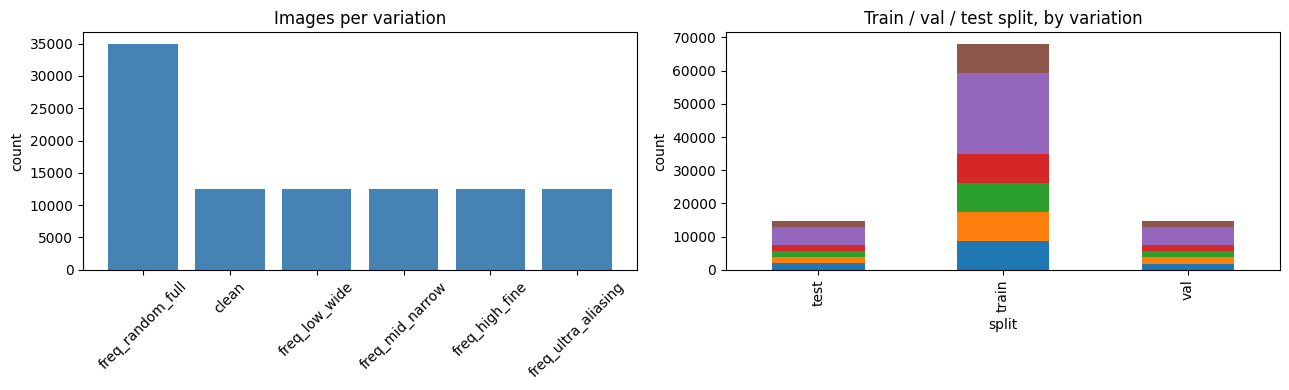

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

variation_counts = df["variation"].value_counts()
axes[0].bar(variation_counts.index, variation_counts.values, color="steelblue")
axes[0].set_title("Images per variation")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("count")

split_counts = df.groupby(["split", "variation"]).size().unstack(fill_value=0)
split_counts.plot(kind="bar", stacked=True, ax=axes[1], legend=False)
axes[1].set_title("Train / val / test split, by variation")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## 2. Class balance — clean vs. attacked (what the CNN actually trains on)

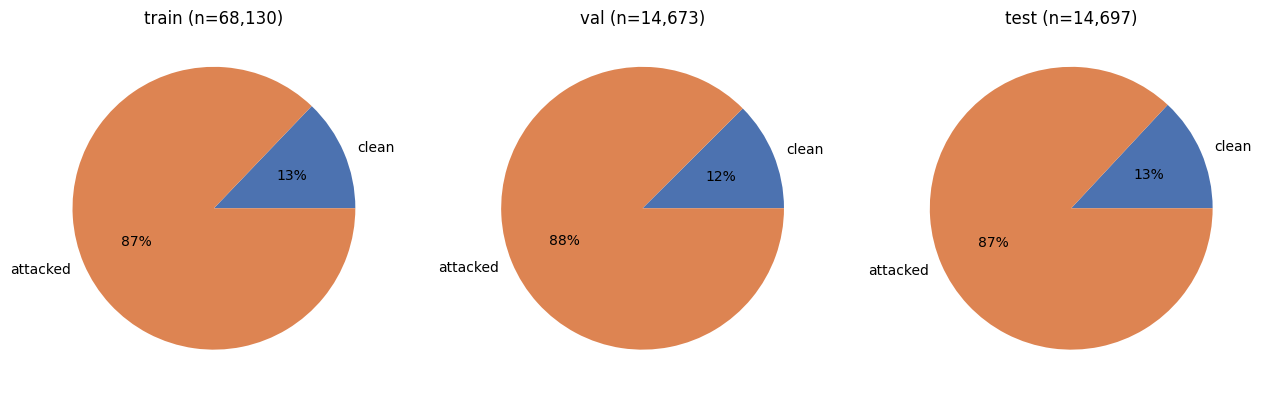

In [5]:
df["binary_label"] = (df["variation"] != "clean").astype(int)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for i, split in enumerate(["train", "val", "test"]):
    sub = df[df["split"] == split]
    counts = sub["binary_label"].value_counts().reindex([0, 1], fill_value=0)
    ax[i].pie(counts, labels=["clean", "attacked"], autopct="%1.0f%%",
              colors=["#4C72B0", "#DD8452"])
    ax[i].set_title(f"{split} (n={len(sub):,})")
plt.tight_layout()
plt.show()

## 3. Sample images per variation

Quick visual gut-check: does each variation actually look like what its name
claims? (`freq_low_wide` = broad soft bands, `freq_ultra_aliasing` = tight
fine bands, `clean` = untouched, etc.)

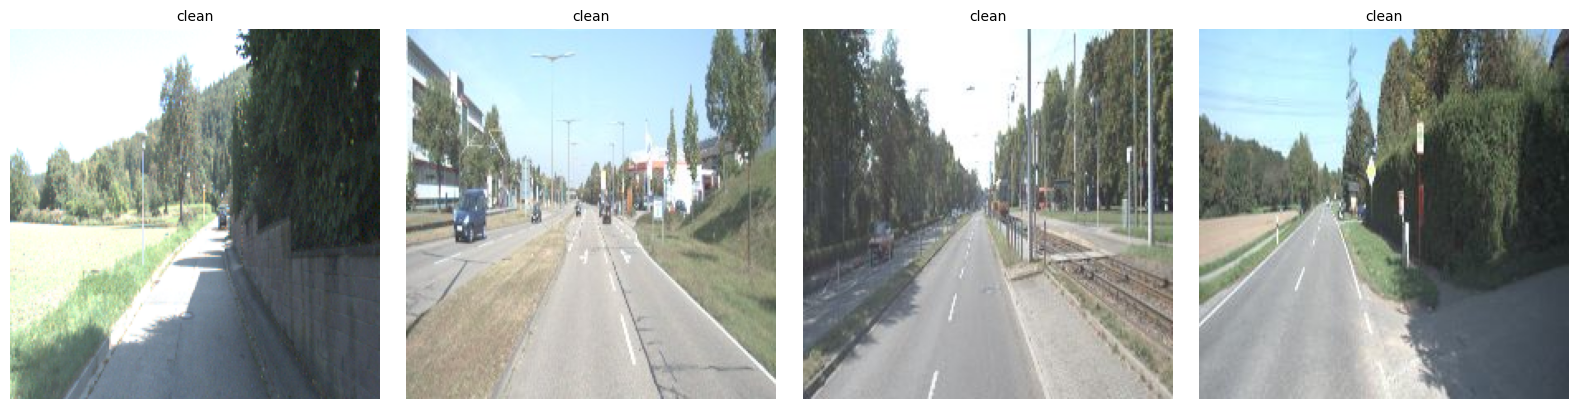

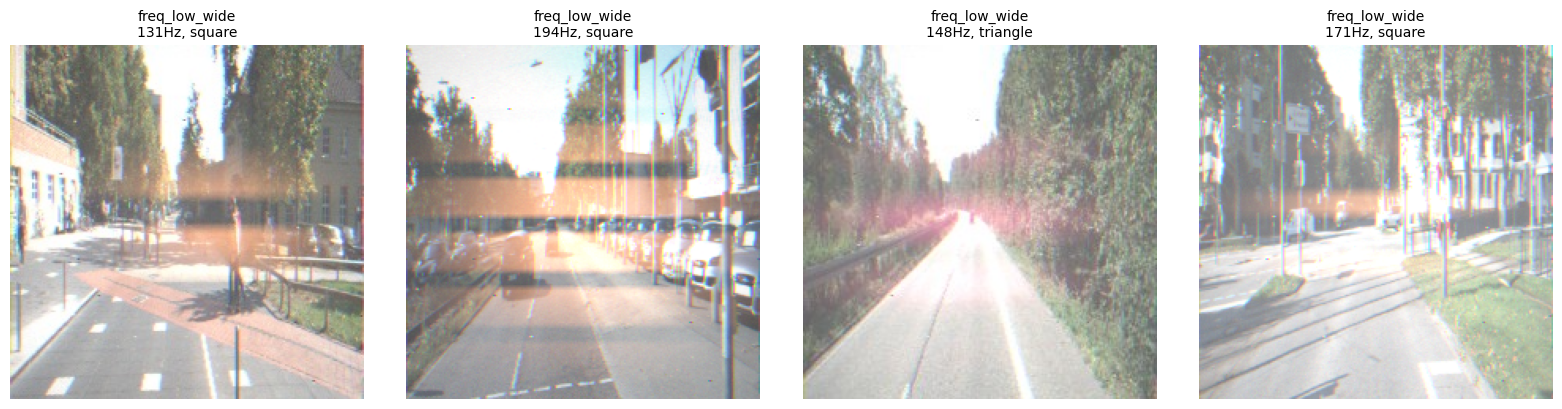

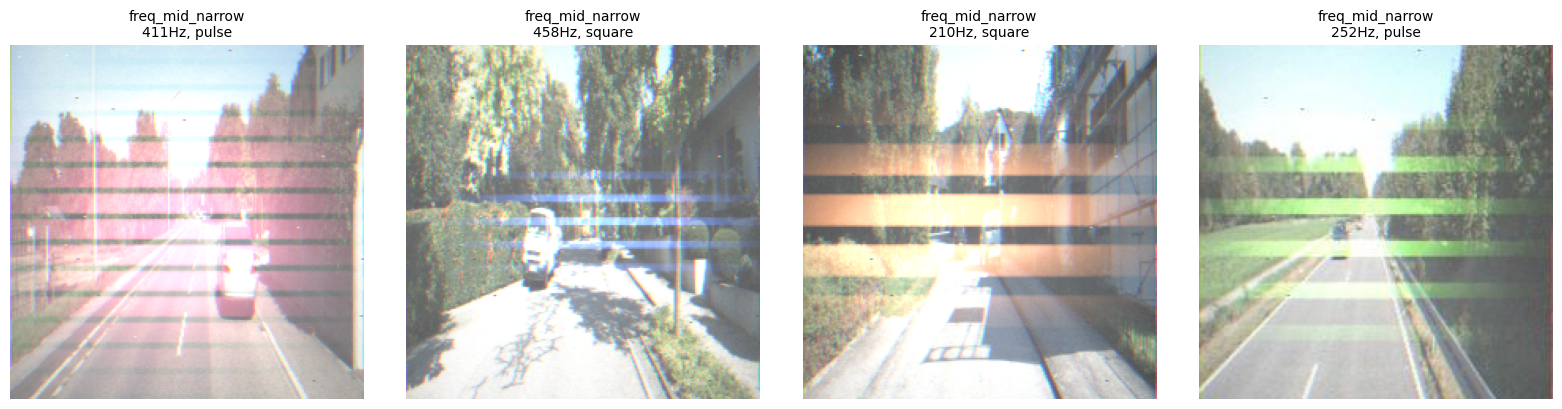

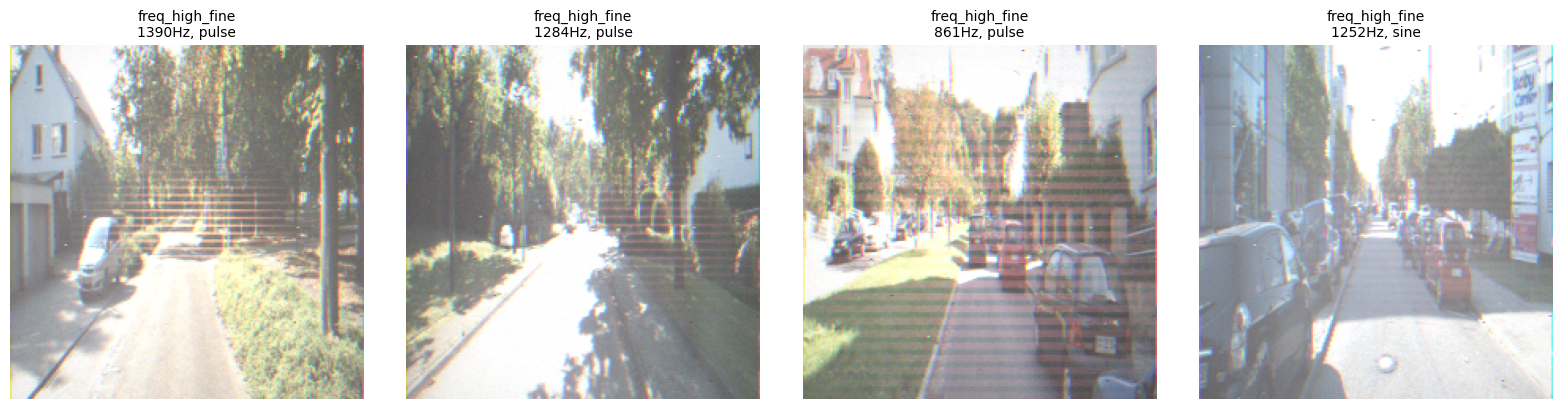

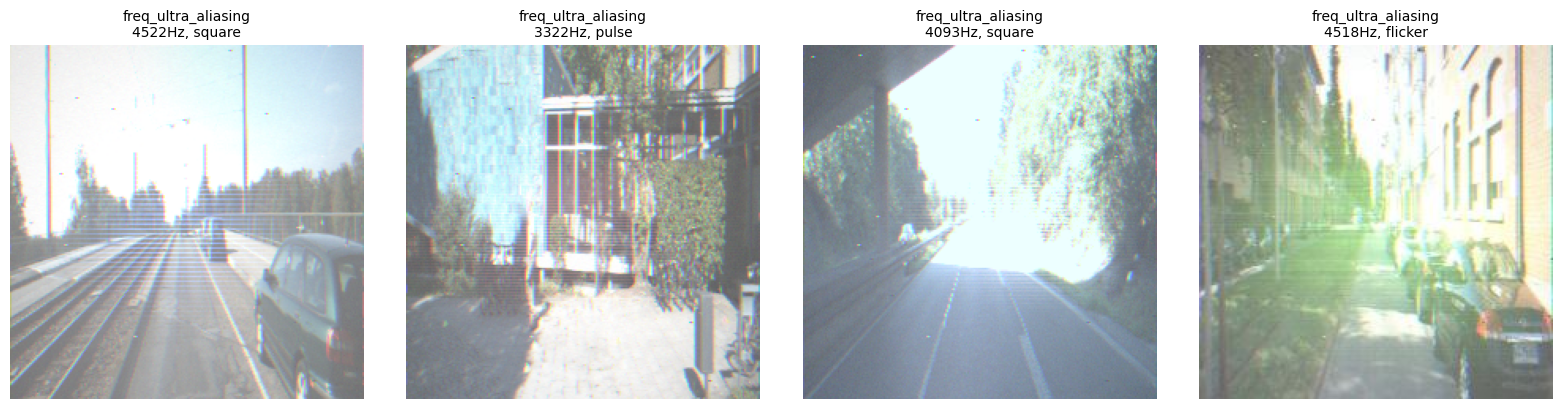

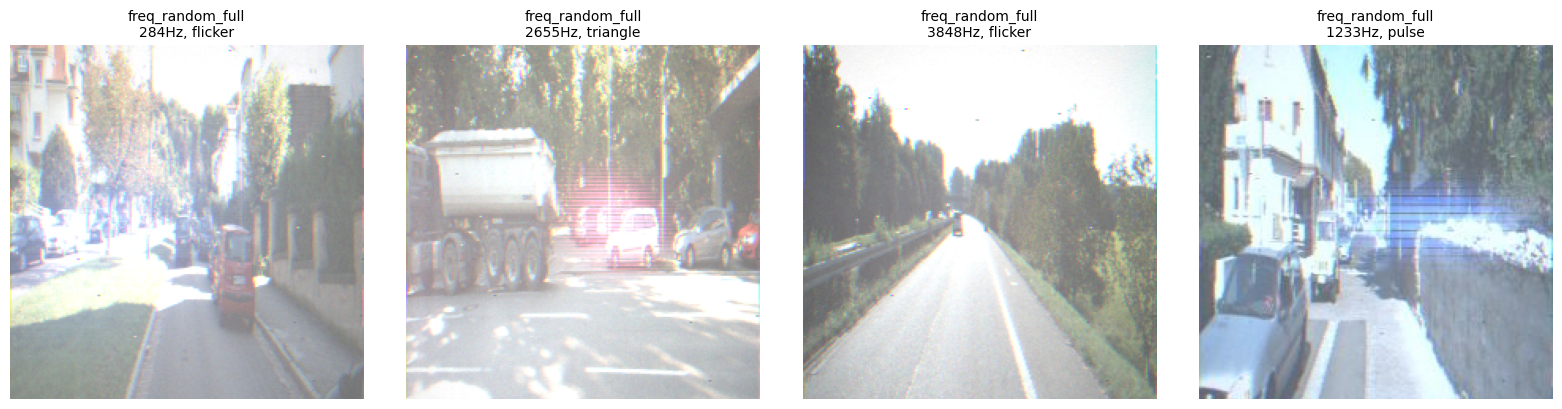

In [6]:
def show_variation_samples(variation, n=4, seed=0):
    rows = df[df["variation"] == variation].sample(n=min(n, len(df[df["variation"]==variation])), random_state=seed)
    fig, axes = plt.subplots(1, len(rows), figsize=(4*len(rows), 4))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img = cv2.cvtColor(cv2.imread(str(DATASET_ROOT / row["path"])), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        title = variation
        if variation != "clean":
            title += f"\n{row['frequency']:.0f}Hz, {row['modulation']}"
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for variation in df["variation"].unique():
    show_variation_samples(variation, n=4)

## 4. Frequency distribution per variation (confirms bands don't overlap unexpectedly)

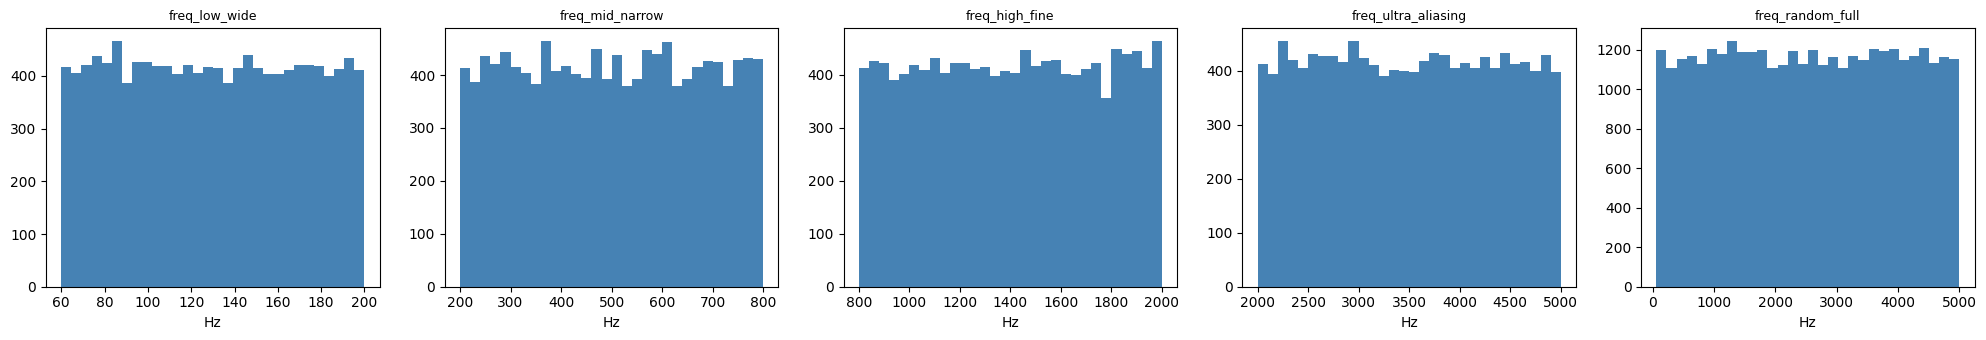

In [9]:
attacked = df[df["variation"] != "clean"]
variations = [v for v in attacked["variation"].unique()]

fig, axes = plt.subplots(1, len(variations), figsize=(4*len(variations), 3.5), sharey=False)
for ax, v in zip(axes, variations):
    sub = attacked[attacked["variation"] == v]
    ax.hist(sub["frequency"], bins=30, color="steelblue")
    ax.set_title(v, fontsize=9)
    ax.set_xlabel("Hz")
plt.tight_layout()
plt.show()

## 5. Stripe-contrast audit (the exposure_time fix, visualized)

Recomputes each attacked image's row-power contrast from its logged
frequency/modulation/exposure_time — the same check as
`audit_stripe_contrast.py`, but plotted here so you have a figure for your
mentor rather than just a printed table.

In [8]:
FPS = cfg["camera"]["fps"]
HEIGHT = cfg["camera"]["height"]

def row_power_std(freq, modulation, duty, texp, phase=0.0, num_samples=24, seed=0):
    if freq <= 0:
        return 0.0
    frame_time = 1.0 / FPS
    row_time = frame_time / HEIGHT
    rows = np.arange(HEIGHT)
    t_start = rows * row_time
    offsets = np.linspace(0.0, texp, num_samples)
    T = t_start[:, None] + offsets[None, :]
    period = 1.0 / freq
    ph = np.mod(T + phase, period)
    if modulation in ("square", "pulse"):
        wave = (ph < duty * period).astype(np.float32)
    elif modulation == "sine":
        wave = (np.sin(2*np.pi*ph/period) + 1) / 2
    elif modulation == "triangle":
        half = period / 2
        wave = np.where(ph < half, ph/half, 2 - ph/half)
    else:
        wave = np.random.default_rng(seed).random((HEIGHT, num_samples))
    return float(wave.mean(axis=1).std())

exposure_col = "exposure_time" if "exposure_time" in attacked.columns else None
if exposure_col is None:
    print("No exposure_time column found (older dataset generation) - "
          "audit will use the camera default for every row, which will "
          "overstate low-contrast counts for images that used a shorter "
          "per-variation exposure_time in reality.")

def compute_std(row):
    texp = row[exposure_col] if exposure_col else cfg["camera"]["exposure_time"]
    if not texp or texp <= 0:
        texp = cfg["camera"]["exposure_time"]
    return row_power_std(row["frequency"], row["modulation"], row["duty_cycle"], texp)

attacked = attacked.copy()
attacked["row_power_std"] = attacked.apply(compute_std, axis=1)

THRESHOLD = 0.08
audit = attacked.groupby("variation")["row_power_std"].agg(
    mean_std="mean",
    pct_low_contrast=lambda s: 100 * (s < THRESHOLD).mean(),
).round(3)
print(audit.to_string())

                     mean_std  pct_low_contrast
variation                                      
freq_high_fine          0.388             0.000
freq_low_wide           0.351             0.000
freq_mid_narrow         0.397             0.000
freq_random_full        0.282            19.871
freq_ultra_aliasing     0.309            33.176


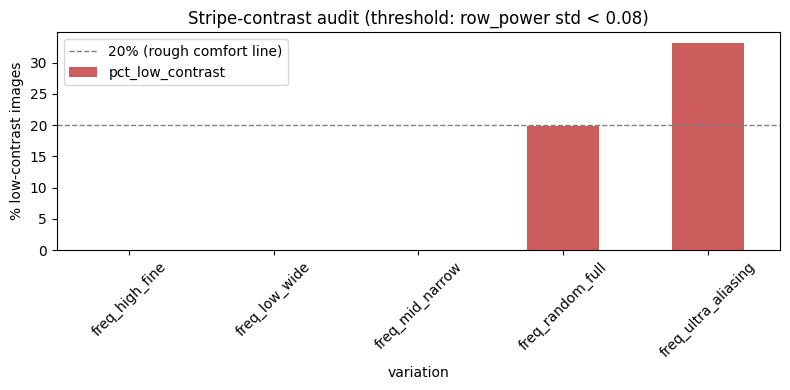

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
audit["pct_low_contrast"].plot(kind="bar", ax=ax, color="indianred")
ax.axhline(20, color="gray", linestyle="--", linewidth=1, label="20% (rough comfort line)")
ax.set_ylabel("% low-contrast images")
ax.set_title(f"Stripe-contrast audit (threshold: row_power std < {THRESHOLD})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Saturation / attack-area metrics per variation

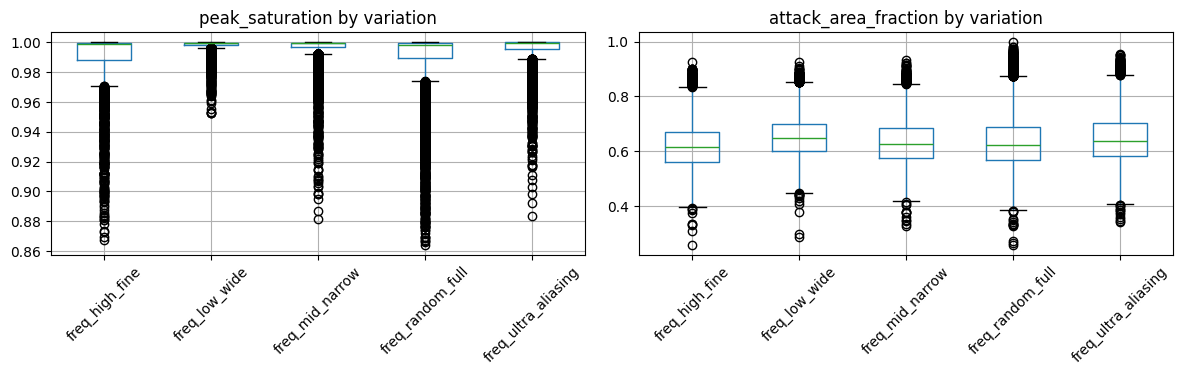

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
attacked.boxplot(column="peak_saturation", by="variation", ax=axes[0], rot=45)
axes[0].set_title("peak_saturation by variation")
axes[0].set_xlabel("")
plt.suptitle("")

attacked.boxplot(column="attack_area_fraction", by="variation", ax=axes[1], rot=45)
axes[1].set_title("attack_area_fraction by variation")
axes[1].set_xlabel("")
plt.suptitle("")

plt.tight_layout()
plt.show()

## Summary checklist before training

- [ ] Class balance (section 2) looks reasonable per split
- [ ] Sample images (section 3) visually match each variation's name
- [ ] Frequency histograms (section 4) land inside the expected band per variation
- [ ] Stripe-contrast audit (section 5) shows low `pct_low_contrast` across all variations
- [ ] No variation is a huge outlier in saturation/attack-area (section 6)

If all of the above look reasonable, proceed to:
```
python run.py --mode test
python run.py --mode train --model ensemble
```